### Changed direction: `AerSimulator` with customised connectivity graph

This is inspired by Rigetti's 9-qubit Novera device, which is a square lattice layout.

```
0 - 1 - 2
|   |   |
3 - 4 - 5
|   |   |
6 - 7 - 8
```

In [1]:
from qiskit_aer import AerSimulator
import networkx as nx

In [2]:
from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.circuit.library import CXGate, HGate, RXGate, RYGate
from qiskit.transpiler import Target, CouplingMap

In [3]:
# Make a customised coupling map
# CouplingMap.from_grid(3, 3, bidirectional=True) also leads to the same result.
cmap = CouplingMap.from_grid(4, 4, bidirectional=True)
'''
cmap = CouplingMap([[0, 1],
                    [1, 2],
                    [0, 3],
                    [1, 4],
                    [2, 5],
                    [3, 4],
                    [4, 5],
                    [3, 6],
                    [4, 7],
                    [5, 8],
                    [6, 7],
                    [7, 8]])
'''

# cmap.make_symmetric()

'\ncmap = CouplingMap([[0, 1],\n                    [1, 2],\n                    [0, 3],\n                    [1, 4],\n                    [2, 5],\n                    [3, 4],\n                    [4, 5],\n                    [3, 6],\n                    [4, 7],\n                    [5, 8],\n                    [6, 7],\n                    [7, 8]])\n'

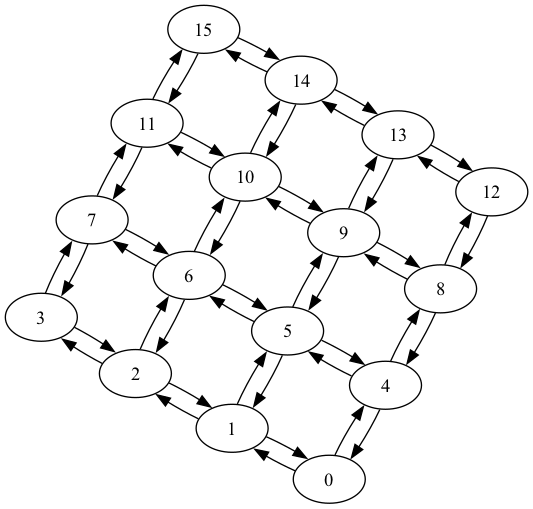

In [4]:
cmap.draw()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness

In [6]:
# Define connectivity: This represents a square lattice of 9 qubits.
# circ = QuantumCircuit(9)

# custom noisy backend (or an attempt at one, at least)
class NoisyBackend(GenericBackendV2):
    def __init__(
        self,
        num_qubits: int,
        basis_gates: list[str] | None = None,
        coupling_map: list[list[int]] = None,
        p1: float = 0,
        p2: float = 0,
    ):
        self.p = (p1, p2)
        super().__init__(
            num_qubits,
            basis_gates,
            coupling_map=coupling_map,
            noise_info=(p1 > 0 or p2 > 0),
        )

    def _get_noise_defaults(self, name: str, num_qubits: int) -> tuple:
        if name in ["delay", "reset"]:
            return (self.p[0], self.p[0])
        else:
            if num_qubits == 1:
                return (0, 0, self.p[0], self.p[0])
            else:
                return (0, 0, self.p[1], self.p[1])

In [25]:
# This bit is for big coupling maps which requires a stabilizer.
# 4x4 coupling map failed to run.

import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

'''
# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)
'''

# Define parameters for the simulated backend
num_qubits = 16
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle

shots = 10000
lengths = [2]+[4,10,20,50,100]
num_samples = 20
 
cmap = CouplingMap.from_grid(4, 4, bidirectional=True)

# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])),  # Pauli Z gate
        "rz": Operator([[np.cos(rz_angle / 2), -1j*np.sin(rz_angle / 2)],
                        [-1j*np.sin(rz_angle / 2), np.cos(rz_angle / 2)]]),  # RZ(π/2)
        "cx": Operator(np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])),  # CNOT gate
    }
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    # seed_simulator=SEED
)

# Set up the experiment object
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=1.0, # aim for 1.0 and 0.5 for mirror_qa_topo (0.25 from Fez)
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='matching' # 'edge_grab', 'matching'
    # seed=SEED
)

# Set run options
exp.set_run_options(shots=shots)

rb_data = exp.run()
print(rb_data.job_ids)

for i in range(20):
    print(f"Pairs from round {i}", exp._pairs[i])

['11ebd0ff-127f-4705-a349-960bda2f2a29']
Pairs from round 0 [(10, 11), (0, 4), (1, 5), (12, 13), (7, 6), (9, 8), (3, 2), (14, 15)]
Pairs from round 1 [(13, 14), (1, 2), (0, 4), (3, 7), (10, 6), (11, 15), (8, 12), (5, 9)]
Pairs from round 2 [(0, 1), (11, 7), (2, 3), (5, 6), (4, 8), (13, 12), (10, 9), (14, 15)]
Pairs from round 3 [(9, 10), (13, 14), (15, 11), (0, 4), (5, 1), (2, 3), (6, 7), (8, 12)]
Pairs from round 4 [(0, 4), (5, 1), (13, 9), (6, 10), (8, 12), (3, 2), (7, 11), (14, 15)]
Pairs from round 5 [(1, 2), (10, 11), (9, 13), (0, 4), (7, 3), (5, 6), (8, 12), (14, 15)]
Pairs from round 6 [(0, 1), (10, 11), (9, 13), (5, 4), (7, 3), (2, 6), (8, 12), (14, 15)]
Pairs from round 7 [(0, 4), (1, 5), (14, 10), (2, 3), (6, 7), (13, 9), (11, 15), (12, 8)]
Pairs from round 8 [(0, 1), (15, 14), (12, 13), (10, 6), (4, 8), (5, 9), (3, 2), (7, 11)]
Pairs from round 9 [(10, 11), (15, 14), (3, 7), (9, 5), (2, 6), (13, 12), (4, 8), (1, 0)]
Pairs from round 10 [(6, 2), (9, 13), (0, 4), (1, 5), (10, 

In [ ]:
# exp.analysis.set_options(analyzed_quantity="Effective Polarization")
exp.analysis.set_options(analyzed_quantity='Mutual Information')

In [ ]:
analysis = exp.analysis.run(rb_data)

In [ ]:
# job id: '241e77fa-032a-4a95-9c6b-f182a12a260f' (from Mon 9 Feb 17:54)
# print(rb_data)

In [7]:
p = 1e-2

backend = NoisyBackend(
    num_qubits=16, # based on the nxn grid
    coupling_map=cmap.get_edges(), 
    basis_gates=["id", "h", "x", "y", "z", "rx", "cx"],
    p1=p / 10,
    p2=p,
    )

In [8]:
# number of shots per circuit
shots = 10000

# lengths of different mirror circuits to run
lengths = [2] + [4, 10, 20, 50, 100]

# set up the experiment object
exp = MirrorQA(
    range(backend.num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=1.0, # aim for 1.0 and 0.5 for mirror_qa_topo
    num_samples=20,
    initial_entangling_angle=np.pi / 2, # I was using non-Clifford gates... (np.pi / 4)
    sampling_algorithm='edge_grab' # 'edge_grab', 'matching'
)
exp.set_run_options(shots=shots)

In [9]:
rb_data = exp.run()
print(rb_data.job_ids)

/Users/astrydpark/Documents/GitHub/qiskit-device-benchmarking/qiskit_device_benchmarking/utilities/sampling_utils.py:425: UserWarning: Mean number of two-qubit gates is higher than the number of selected edges. Actual density of two-qubit gates will likely be lower than input density.
  warnings.warn(


['039c95ea-28a2-437b-82b2-bd71c8139052']


Simulation failed and returned the following error message:
PARTIAL COMPLETED
Job data not added for errored job [Job ID: 039c95ea-28a2-437b-82b2-bd71c8139052]
Error message: 
Job data not added for errored job [Job ID: c9fc3db2-1195-4f6d-b962-e89d5af9d72a]
Error message: 


In [10]:
for i in range(20):
    print(f"Pairs from round {i}", exp._pairs[i])

# print("Pairs:", exp._pairs[0])
# --> The entangling gates from the first round affected these pairs.
# --> Is it randomly different from each round?

# exp._static_trans_circuits[0].draw(fold=-1)

Pairs from round 0 [(0, 1), (8, 12), (3, 2), (4, 5), (10, 6), (13, 14), (7, 11)]
Pairs from round 1 [(14, 10), (0, 1), (4, 5), (7, 3), (9, 13), (6, 2), (12, 8), (11, 15)]
Pairs from round 2 [(8, 9), (0, 1), (15, 11), (10, 14), (5, 4), (7, 6), (3, 2), (12, 13)]
Pairs from round 3 [(15, 11), (10, 6), (2, 1), (8, 9), (13, 14), (4, 0), (3, 7)]
Pairs from round 4 [(9, 13), (5, 4), (12, 8), (11, 10), (7, 3), (1, 0), (15, 14), (2, 6)]
Pairs from round 5 [(8, 12), (5, 4), (2, 1), (10, 9), (7, 11), (15, 14)]
Pairs from round 6 [(9, 8), (2, 1), (4, 0), (6, 10), (15, 11), (13, 12), (7, 3)]
Pairs from round 7 [(13, 12), (6, 5), (2, 1), (15, 11), (3, 7), (0, 4), (9, 8), (10, 14)]
Pairs from round 8 [(13, 12), (3, 2), (5, 4), (10, 11), (15, 14), (6, 7), (8, 9), (0, 1)]
Pairs from round 9 [(1, 5), (13, 12), (6, 7), (4, 8), (14, 15), (9, 10), (2, 3)]
Pairs from round 10 [(7, 11), (6, 5), (10, 14), (2, 1), (0, 4), (12, 8), (9, 13)]
Pairs from round 11 [(2, 6), (11, 15), (0, 4), (10, 14), (9, 13), (1, 5

In [35]:
exp._static_trans_circuits[0].draw(fold=-1)

global phase: π
         ┌───┐ ░      ┌─────────┐┌──────────┐   ┌───┐                                  ░ ┌───┐ ░ ┌──────────┐   ┌───┐                         ░       ░  ░ ┌─┐                                             
    q_0: ┤ Y ├─░───■──┤ Rx(π/4) ├┤ Rx(-π/2) ├───┤ Z ├──────────────────────────────────░─┤ X ├─░─┤ Rx(-π/2) ├───┤ Z ├────────────────■────────░───────░──░─┤M├─────────────────────────────────────────────
         ├───┤ ░   │  └─────────┘├─────────┬┘   ├───┤    ┌─────────┐    ┌───┐    ┌───┐ ░ ├───┤ ░ └──┬───┬───┘┌──┴───┴──┐ ┌───┐┌───┐  │        ░ ┌───┐ ░  ░ └╥┘┌─┐                                          
    q_1: ┤ Y ├─░───┼───────■─────┤ Rx(π/4) ├────┤ H ├────┤ Rx(π/2) ├────┤ H ├────┤ Y ├─░─┤ X ├─░────┤ H ├────┤ Rx(π/2) ├─┤ H ├┤ Y ├──┼────■───░─┤ X ├─░──░──╫─┤M├──────────────────────────────────────────
         ├───┤ ░   │       │     └──┬───┬──┘    ├───┤    ├─────────┴┐   ├───┤    └───┘ ░ ├───┤ ░ ┌──┴───┴──┐ └──┬───┬──┘ ├───┤├───┤  │    │   ░ └───┘ ░  ░  ║ └╥┘┌─┐                                       
    q_2: ┤ X ├─░───┼───────┼────────┤ X ├───────┤ H ├────┤ Rx(-π/2) ├───┤ Y ├──────────░─┤ X ├─░─┤ Rx(π/2) ├────┤ H ├────┤ X ├┤ X ├──┼────┼───░───────░──░──╫──╫─┤M├───────────────────────────────────────
         ├───┤ ░   │       │        └─┬─┘    ┌──┴───┴──┐ └──┬───┬───┘┌──┴───┴───┐┌───┐ ░ └───┘ ░ ├─────────┤    ├───┤    ├───┤└─┬─┘  │    │   ░ ┌───┐ ░  ░  ║  ║ └╥┘┌─┐                                    
    q_3: ┤ Y ├─░───┼───────┼──────────■──────┤ Rx(π/4) ├────┤ H ├────┤ Rx(-π/2) ├┤ Z ├─░───────░─┤ Rx(π/2) ├────┤ H ├────┤ Y ├──■────┼────┼───░─┤ X ├─░──░──╫──╫──╫─┤M├────────────────────────────────────
         ├───┤ ░ ┌─┴─┐     │        ┌───┐    ├─────────┴┐   ├───┤    └──────────┘└───┘ ░       ░ ├─────────┤    ├───┤    ├───┤     ┌─┴─┐  │   ░ ├───┤ ░  ░  ║  ║  ║ └╥┘┌─┐                                 
    q_4: ┤ Y ├─░─┤ X ├─────┼────────┤ H ├────┤ Rx(-π/2) ├───┤ Z ├──────────────────────░───────░─┤ Rx(π/2) ├────┤ H ├────┤ Y ├─────┤ X ├──┼───░─┤ X ├─░──░──╫──╫──╫──╫─┤M├─────────────────────────────────
         ├───┤ ░ └───┘   ┌─┴─┐      ├───┤    └──────────┘   └───┘                      ░ ┌───┐ ░ └──┬───┬──┘    └───┘    └───┘     └───┘┌─┴─┐ ░ ├───┤ ░  ░  ║  ║  ║  ║ └╥┘┌─┐                              
    q_5: ┤ Y ├─░─────────┤ X ├──────┤ Z ├──────────────────────────────────────────────░─┤ Z ├─░────┤ Z ├───────────────────────────────┤ X ├─░─┤ Z ├─░──░──╫──╫──╫──╫──╫─┤M├──────────────────────────────
         ├───┤ ░      ┌──┴───┴──┐   └───┘                                              ░ ├───┤ ░    └───┘                               └───┘ ░ ├───┤ ░  ░  ║  ║  ║  ║  ║ └╥┘┌─┐                           
    q_6: ┤ X ├─░───■──┤ Rx(π/4) ├──────────────────────────────────────────────────────░─┤ Z ├─░──────────────────■───────────────────────────░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫─┤M├───────────────────────────
         ├───┤ ░ ┌─┴─┐└──┬───┬──┘                                                      ░ ├───┤ ░    ┌───┐       ┌─┴─┐                         ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                        
    q_7: ┤ X ├─░─┤ X ├───┤ Y ├─────────────────────────────────────────────────────────░─┤ X ├─░────┤ Y ├───────┤ X ├─────────────────────────░─┤ Z ├─░──░──╫──╫──╫──╫──╫──╫──╫─┤M├────────────────────────
         ├───┤ ░ └───┘┌──┴───┴──┐   ┌───┐    ┌─────────┐    ┌───┐                      ░ └───┘ ░    ├───┤    ┌──┴───┴──┐ ┌───┐┌───┐           ░ └───┘ ░  ░  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                     
    q_8: ┤ X ├─░───■──┤ Rx(π/4) ├───┤ H ├────┤ Rx(π/2) ├────┤ H ├──────────────────────░───────░────┤ H ├────┤ Rx(π/2) ├─┤ H ├┤ Z ├───────■───░───────░──░──╫──╫──╫──╫──╫──╫──╫──╫─┤M├─────────────────────
         ├───┤ ░   │  └──┬───┬──┘   ├───┤    ├─────────┴┐   └───┘                      ░ ┌───┐ ░ ┌──┴───┴──┐ └──┬───┬──┘ └───┘└───┘┌───┐  │   ░ ┌───┐ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                  
    q_9: ┤ X ├─░───┼─────┤ X ├──────┤ H ├────┤ Rx(-π/2) ├──────────────────────────────░─┤ X ├─░─┤ Rx(π/2) ├

In [11]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
# exp.analysis.set_options(analyzed_quantity='Mutual Information')
analysis = exp.analysis.run(rb_data)

In [12]:
print(rb_data)

---------------------------------------------------
Experiment: MirrorQA
Experiment ID: 2464c8b2-7647-45f6-beeb-5bdbe635b9d0
Status: ExperimentStatus.ERROR
Backend: <__main__.NoisyBackend object at 0x17f139f90>
Data: 0
Analysis Results: 0
Figures: 0
Artifacts: 0


In [13]:
print(exp.analysis.results)

AttributeError: 'MirrorQAAnalysis' object has no attribute 'results'

In [39]:
analysis.figure(0)

ExperimentEntryNotFound: 'Figure index 0 out of range.'

In [29]:
# Mutual Intormation calculated by QuantumAwesomeness class

qa = QuantumAwesomeness(exp.backend.coupling_map)

Provider for ExperimentData object doesn't exist, resulting in a failed attempt to retrieve data from the server; no stored result data exists
Provider for ExperimentData object doesn't exist, resulting in a failed attempt to retrieve data from the server; no stored result data exists
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fro

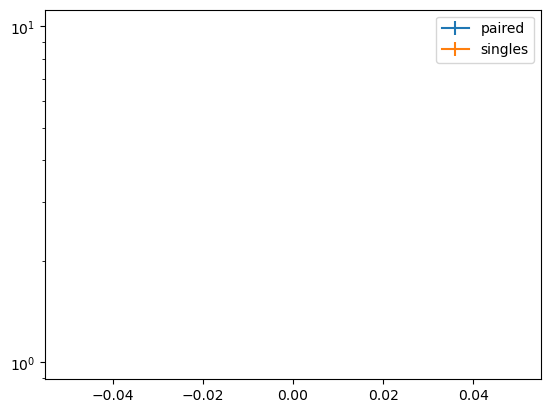

In [30]:
mi = qa.mutual_info(rb_data.data())

mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % 6].append(m)
    for j in range(6):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()